#**Installation, Mounting, and Dataset Loading**

In [ ]:
!pip install pandas numpy matplotlib scikit-learn seaborn

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Open zip files for reading
import pandas as pd
import os

file_path = '/content/drive/My Drive/airbnb_cleaned_data.csv'

if file_path.endswith('.gz'):
        # This block runs if the file name ends with .gz
        df = pd.read_csv(file_path, compression='gzip')

elif file_path.endswith('.csv'):
        # This block runs if it ends with .csv
        df = pd.read_csv(file_path)
# pd.set_option('display.max_columns', None)
# Check if it worked
df.head()

,id,price,host_id,host_since,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_identity_verified,host_experience_years,...,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,unique_reviewers_count,reviewer_diversity,rating_consistency
0,3781,125.0,4804.0,2008-12-03,1.00,0.19,1.0,3.0,0.0,16.945205,...,4.96,5.00,4.96,5.00,4.96,4.85,4.88,25.0,0.961538,0.945453
1,5506,129.0,8229.0,2009-02-19,1.00,1.00,1.0,12.0,1.0,16.731507,...,4.82,4.89,4.91,4.95,4.90,4.58,4.77,138.0,1.000000,0.887980
2,6695,168.0,8229.0,2009-02-19,1.00,1.00,1.0,12.0,1.0,16.731507,...,4.81,4.83,4.86,4.90,4.94,4.54,4.72,141.0,1.000000,0.881610
3,8789,140.0,26988.0,2009-07-22,1.00,0.37,1.0,8.0,1.0,16.312329,...,4.69,4.69,4.55,4.93,4.97,4.97,4.59,28.0,0.965517,0.845874
4,10811,166.0,38997.0,2009-09-16,0.94,0.59,0.0,21.0,1.0,16.158904,...,4.33,4.44,4.67,4.56,4.00,5.00,4.67,9.0,1.000000,0.761313


#**Data Splitting and Scaling**

In [ ]:
# Anh Ha
# Split data into 8:1:1 for training, validation and test sets
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler

# Load file
file_name = '/content/drive/My Drive/airbnb_cleaned_data.csv'
df = pd.read_csv(file_name)

#print(f"Loaded data with {df.shape[0]} rows and {df.shape[1]} columns.")
#print(df.head()) # Print first 5 rows to check

# --- Separate Features (X) and Target (y) ---
feature_columns = [

    # Core Property Features
    'accommodates',
    'bathrooms',
    'room_type_encoded',
    'instant_bookable',
    'minimum_nights',
    'maximum_nights',
    'availability_30',

    # Location
    'distance_to_center',

    # Controllable Features

    # Host Performance
    #'host_response_rate',
    'host_is_superhost',
    'host_acceptance_rate', # the rate that host accecpt order

    # amenities
    'has_wifi',
    'has_kitchen',
    'has_air_conditioning',
    'has_heating',
    'has_washer',
    'has_dryer',
    'has_tv',
    'has_parking',
    'has_gym',
    'has_pet_friendly',

    #reviews
    #'neighborhood_density',
    'room_type_density',
    'number_of_reviews',
    'review_scores_rating',
    'review_scores_accuracy', 'review_scores_cleanliness',
    'review_scores_checkin', 'review_scores_communication',
    'review_scores_location', 'review_scores_value'

]
target_column = 'price'

y = np.log1p(df[target_column])
X = df[feature_columns]


# First Split (80% train, 20% temp)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42,
    stratify=X['room_type_encoded']  # STRATIFY on the 'room_type' column.
)

# Second Split (half of temp to val, half to test)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42,
)

# Uncomment to check Results
# print("\nSplitting complete.")
# print(f"Training set:   {X_train.shape[0]} rows")
# print(f"Validation set: {X_val.shape[0]} rows")
# print(f"Test set:       {X_test.shape[0]} rows")

# print("\n--- Check: 'room_type_encoded' distribution ---")
# # Should be nearly identical
# print("\nOriginal:\n", X['room_type_encoded'].value_counts(normalize=True))
# print("\nTraining:\n", X_train['room_type_encoded'].value_counts(normalize=True))
# print("\nValidation:\n", X_val['room_type_encoded'].value_counts(normalize=True))
# print("\nTest:\n", X_test['room_type_encoded'].value_counts(normalize=True))

# Scaling data for features that are on different scales
continuous_features = [

    'accommodates',
    'bathrooms',
    'distance_to_center',
    #'host_response_rate',
    'host_acceptance_rate',
    'minimum_nights',
    'maximum_nights',
    'availability_30',
    'number_of_reviews',
    'review_scores_rating',
    'review_scores_accuracy', 'review_scores_cleanliness',
    'review_scores_checkin', 'review_scores_communication',
    'review_scores_location', 'review_scores_value'
]

# Initialize
scaler = StandardScaler()

# Fit on training data
scaler.fit(X_train[continuous_features])

# Store Results
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

#Transform
X_train_scaled[continuous_features] = scaler.transform(X_train[continuous_features])
X_val_scaled[continuous_features] = scaler.transform(X_val[continuous_features])
X_test_scaled[continuous_features] = scaler.transform(X_test[continuous_features])

# Results
print("--- Original X_train ---")
print(X_train[continuous_features].head())
print("\n")

print("--- Scaled X_train (features are now centered around 0) ---")
print(X_train_scaled[continuous_features].head())

--- Original X_train ---
      accommodates  bathrooms  distance_to_center  host_acceptance_rate  \
1740           2.0        1.0            3.126843                  0.96   
1823           4.0        1.5            5.938808                  0.95   
2889           1.0        1.0            0.365836                  0.93   
369            4.0        1.0            3.123361                  0.99   
1841           6.0        2.5            1.090380                  1.00   

      minimum_nights  maximum_nights  availability_30  number_of_reviews  \
1740            45.0           270.0              0.0                7.0   
1823             3.0           365.0              4.0               45.0   
2889            29.0           365.0             11.0                0.0   
369              3.0           730.0              5.0              218.0   
1841             3.0           365.0             19.0               23.0   

      review_scores_rating  review_scores_accuracy  review_scores_c

#**Correlation Exploration and Modeling**

In [ ]:
# Christina Tran

df2 = df.drop(['host_since'], axis=1)
df2.head()
corr_matrix = round(df2.corr(),5) # round 5 decimal places
corr_matrix # nxn table for n features w correlations

#see correlations for one feature
corrs = corr_matrix['price']
corrs

#sort correaltions
corrs_sorted = corrs.sort_values(ascending=False)
print("Correlations of all features to price, sorted in descending order:")
print(corrs_sorted)


Correlations of all features to price, sorted in descending order:
price                    1.00000
accommodates             0.57799
bathrooms                0.46287
bedrooms                 0.46018
instant_bookable         0.22217
                          ...   
distance_to_airport     -0.22068
distance_to_mit         -0.23773
property_type_encoded   -0.27182
distance_to_center      -0.27880
room_type_encoded       -0.41547
Name: price, Length: 61, dtype: float64


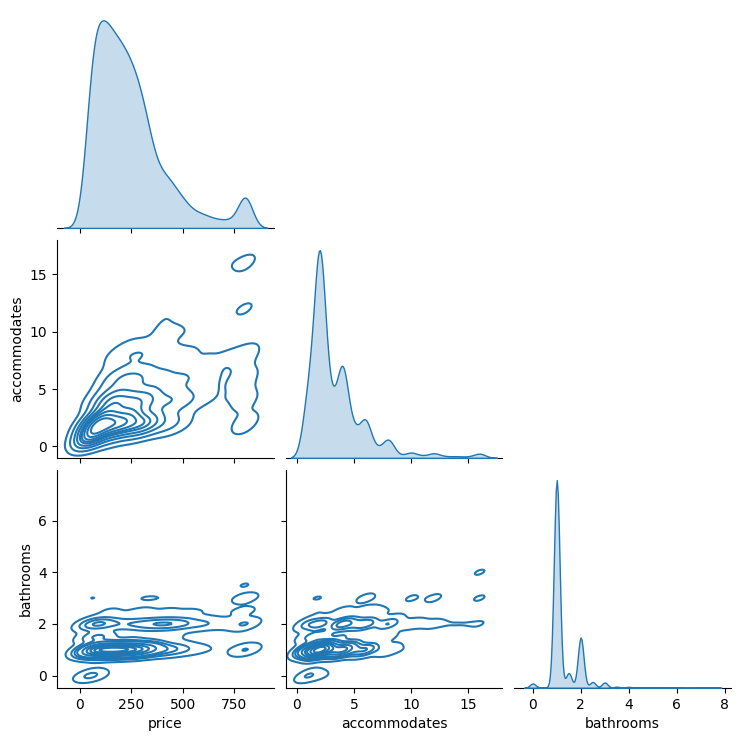

In [ ]:
# Christina Tran

import seaborn as sns
#plot price label and its top 2 highest correlates
df_corrs = df2[['price', 'accommodates', 'bathrooms']]
df_corrs

#make seaborn pairplot, kernel density estimater
sns.pairplot(data=df_corrs, kind='kde', corner=True)

# Observations from the pairplot:
* **Price** is skewed with a tail to the right, exhibiting that most
listings have relatively low to moderate prices in comparison on the range of prices. There are some high price outliers.
* **Accommodates** is very right skewed with most listing accommodating 2-5 people, rarely more than 10.
* **Bathrooms** is highly concentrated around 1 bathroom with smaller spikes around 2 bathrooms. Very few listings appear to lie on the higher count.
* **Price vs Accommodates** displays that in general, price increases as accommodates increases. The most dense region is the accommodates range of 1-4 at the low
to mid range price. Although there is a general positive trend, there appears to be more variance in the cost of greater-accommodate listings (towards the right). This graph reflects the moderately positive correlation of 0.57799 between the two variables.
* **Price vs Bathrooms** has a weaker positive correlation (0.46287) but still supports that price increases in general as bathrooms increase. The density in the graph is concentrated at listings with between 1-2 bathrooms at the lower price points.
* **Accommodates vs Bathrooms** appears to have a clearer positive trend of listings that hold more accommodates generally having more bathrooms, which is an intuitive correlation. As the listing has greater capacity for people, it will generally have more bathrooms to accommodate such people. The most dense area is in the 1-4 accommodate region with 1-2 bathrooms. There are much fewser high capacioty listings (10-15 accommodates) with 3 or more bathrooms.

#**Simplified Linear Regression Model(Base Line)**

In [ ]:
# Anh Ha
# Linear Regression Model
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score

lr_baseline = LinearRegression()

# Baseline model: Simple linear Regression
# Choose the top 2 important feature
base_features = ['instant_bookable', 'accommodates']
lr_baseline.fit(X_train_scaled[base_features], y_train)

base_train_predictions = lr_baseline.predict(X_train_scaled[base_features])
base_validation_predictions = lr_baseline.predict(X_val_scaled[base_features])
base_test_predictions = lr_baseline.predict(X_test_scaled[base_features])

base_r2_train = lr_baseline.score(X_train_scaled[base_features], y_train)
base_mae_train_log = mean_absolute_error(y_train,base_train_predictions)
base_mae_train_dollar = mean_absolute_error(np.expm1(y_train),
                                            np.expm1(base_train_predictions))


base_r2_val =lr_baseline.score(X_val_scaled[base_features], y_val)
base_mae_val_log = mean_absolute_error(y_val, base_validation_predictions)
base_mae_val_dollar = mean_absolute_error(np.expm1(y_val),
                                            np.expm1(base_validation_predictions))


base_r2_test = lr_baseline.score(X_test_scaled[base_features], y_test)
base_mae_test_log = mean_absolute_error(y_test, base_test_predictions)
base_mae_test_dollar = mean_absolute_error(np.expm1(y_test),
                                            np.expm1(base_test_predictions))


print("\n--- Baseline Model: Simple Linear Regression Model Evaluation ---")
print(f"\nFeatures considered: {base_features}")
print("\n--- Training Set ---")
print(f"Training R-squared (R²): {base_r2_train:.4f}")
print(f"Training Mean Absolute Error (MAE) Log-Scale: {base_mae_train_log:.4f}")
print(f"Training Mean Absolute Error (MAE) Dollar: {base_mae_train_dollar:.4f}")

print("\n--- Validation Set ---")
print(f"Validation R-squared (R²): {base_r2_val:.4f}")
print(f"Validation Mean Absolute Error (MAE) Log-Scale: {base_mae_val_log:.4f}")
print(f"Validation Mean Absolute Error (MAE) Dollar: {base_mae_val_dollar:.4f}")


print("\n--- Test Set ---")
print(f"Test R-squared (R²): {base_r2_test:.4f}")
print(f"Training Mean Absolute Error (MAE) Log-Scale: {base_mae_test_log:.4f}")
print(f"Validation Mean Absolute Error (MAE) Dollar: {base_mae_test_dollar:.4f}")


--- Baseline Model: Simple Linear Regression Model Evaluation ---

Features considered: ['instant_bookable', 'accommodates']

--- Training Set ---
Training R-squared (R²): 0.3715
Training Mean Absolute Error (MAE) Log-Scale: 0.4572
Training Mean Absolute Error (MAE) Dollar: 109.2180

--- Validation Set ---
Validation R-squared (R²): 0.4161
Validation Mean Absolute Error (MAE) Log-Scale: 0.4686
Validation Mean Absolute Error (MAE) Dollar: 112.5796

--- Test Set ---
Test R-squared (R²): 0.3534
Training Mean Absolute Error (MAE) Log-Scale: 0.4634
Validation Mean Absolute Error (MAE) Dollar: 112.1687


# **Linear Regression**

In [ ]:
lr_model = LinearRegression()

# 3-fold cross validation for linear regression
print("\n--- Linear Regression 3-fold Cross-Validation ---")
kf = KFold(n_splits=3, shuffle=True, random_state=42)
pipe = Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())])
lr_cv_r2 = cross_val_score(pipe, X_train_scaled, y_train, cv=kf, scoring='r2')
lr_cv_mae = cross_val_score(pipe, X_train_scaled, y_train, cv=kf, scoring='neg_mean_absolute_error')
lr_cv_mae = -lr_cv_mae

print(f"3-fold cross validation R²: {lr_cv_r2.mean():.4f},(+-: {lr_cv_r2.std():.4f})")
print(f"3-fold cross validation MAE: {lr_cv_mae.mean():.4f}, (+-: {lr_cv_mae.std():.4f})\n")

print("Training the model...")
lr_model.fit(X_train_scaled, y_train)
print("Training complete.")

print("\n--- Linear Regression Model Evaluation ---")

# Predictions for the training test

print("\n--- Training Set ---")
# Get the R-squared (R²) score
# R² tells you how much of the variation in review scores
r2_train = lr_model.score(X_train_scaled,y_train)
# Get the model's predictions for the training set
train_predictions = lr_model.predict(X_train_scaled)
# Calculate Mean Absolute Error (MAE)
mae_train_log = mean_absolute_error(y_train, train_predictions)
mae_train_dollar = mean_absolute_error(np.expm1(y_train),np.expm1(train_predictions))

print(f"Training R-squared (R²): {r2_train:.4f}")
print(f"Training Mean Absolute Error (MAE) Log-Scale: {mae_train_log:.4f}")
print(f"Training Mean Absolute Error (MAE) Dollar: {mae_train_dollar:.4f}")

# Predictions for the validation set
print("\n--- Validation Set ---")
r2_validation = lr_model.score(X_val_scaled, y_val)
val_predictions = lr_model.predict(X_val_scaled)
mae_val_log = mean_absolute_error(y_val, val_predictions)
mae_val_dollar = mean_absolute_error(np.expm1(y_val),np.expm1(val_predictions))

print(f"Validation R-squared (R²): {r2_validation:.4f}")
print(f"Validation Mean Absolute Error (MAE) Log-Scale: {mae_val_log:.4f}")
print(f"Validation Mean Absolute Error (MAE) Dollar: {mae_val_dollar:.4f}")

# Predictions for the test set
print("\n--- Testing Set ---")
r2_test = lr_model.score(X_test_scaled, y_test)
test_predictions = lr_model.predict(X_test_scaled)
mae_test_log = mean_absolute_error(y_test, test_predictions)
mae_test_dollar = mean_absolute_error(np.expm1(y_test),np.expm1(test_predictions))

print(f"Test R-squared (R²): {r2_test:.4f}")
print(f"Test Mean Absolute Error (MAE) Log-Scale: {mae_test_log:.4f}")
print(f"Test Mean Absolute Error (MAE) Dollar: {mae_test_dollar:.4f}")



--- Linear Regression 3-fold Cross-Validation ---
3-fold cross validation R²: 0.6505,(+-: 0.0131)
3-fold cross validation MAE: 0.3257, (+-: 0.0036)

Training the model...
Training complete.

--- Linear Regression Model Evaluation ---

--- Training Set ---
Training R-squared (R²): 0.6610
Training Mean Absolute Error (MAE) Log-Scale: 0.3212
Training Mean Absolute Error (MAE) Dollar: 78.5923

--- Validation Set ---
Validation R-squared (R²): 0.7144
Validation Mean Absolute Error (MAE) Log-Scale: 0.3117
Validation Mean Absolute Error (MAE) Dollar: 79.2876

--- Testing Set ---
Test R-squared (R²): 0.6725
Test Mean Absolute Error (MAE) Log-Scale: 0.3219
Test Mean Absolute Error (MAE) Dollar: 82.5692


#**Random Forest Model**


In [ ]:
# Anh Ha
# Random Forest Model
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
from scipy.stats import randint
import numpy as np
import pandas as pd

# n_estimators= build 100 different trees.
# random_state=42 ensures same result every time.
# n_jobs=-1 uses all computer's cores to speed it up.

rf_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1,
                                    max_depth= 15, min_samples_split = 10,
                                 min_samples_leaf = 5, max_features = 'sqrt' )

# 3-fold cross validation for Random Forest
print("\n--- Random Forest 3-fold Cross-Validation ---")
kf = KFold(n_splits=3, shuffle=True, random_state=42)
rf_cv_r2 = cross_val_score(rf_model, X_train_scaled, y_train, cv=kf, scoring='r2')
rf_cv_mae = cross_val_score(rf_model, X_train_scaled, y_train, cv=kf, scoring='neg_mean_absolute_error')
rf_cv_mae = -rf_cv_mae

print(f"3-fold cross validation R²: {rf_cv_r2.mean():.4f},(+-: {rf_cv_r2.std():.4f})")
print(f"3-fold cross validation MAE: {rf_cv_mae.mean():.4f}, (+-: {rf_cv_mae.std():.4f})\n")


print("Training the Random Forest model... (this may take a moment)")
rf_model.fit(X_train_scaled, y_train)
print("Training complete.")

print("\n--- Random Forest Model Evaluation ---")

print("\n--- Training Set ---")
train_predictions_rf = rf_model.predict(X_train_scaled)
r2_train_rf = r2_score(y_train, train_predictions_rf)
mae_train_rf_log = mean_absolute_error(y_train, train_predictions_rf)
mae_train_rf_dollar = mean_absolute_error(np.expm1(y_train), np.expm1(train_predictions_rf))

print(f"Training R-squared (R²): {r2_train_rf:.4f}")
print(f"Training Mean Absolute Error (MAE) Log-Scale: {mae_train_rf_log:.4f}")
print(f"Training Mean Absolute Error (MAE) Dollar: {mae_train_rf_dollar:.4f}")

# --- 2. Validation Set Metrics ---
# (Used for tuning the model and checking for overfitting)
print("\n--- Validation Set ---")
val_predictions_rf = rf_model.predict(X_val_scaled)
r2_validation_rf = r2_score(y_val, val_predictions_rf)
mae_validation_rf_log = mean_absolute_error(y_val, val_predictions_rf)
mae_validation_rf_dollar = mean_absolute_error(np.expm1(y_val), np.expm1(val_predictions_rf))

print(f"Validation log R-squared (R²): {r2_validation_rf:.4f}")
print(f"Validation Mean Absolute Error (MAE) Log-Scale: {mae_validation_rf_log:.4f}")
print(f"Validation Mean Absolute Error (MAE) Dollar: {mae_validation_rf_dollar:.4f}")


# --- 3. Test Set Metrics ---
# (The final, "real" score on unseen data)
print("\n--- Test Set ---")
test_predictions_rf = rf_model.predict(X_test_scaled)
r2_test_rf = r2_score(y_test, test_predictions_rf)
mae_test_rf_log = mean_absolute_error(y_test, test_predictions_rf)
mae_test_rf_dollar = mean_absolute_error(np.expm1(y_test), np.expm1(test_predictions_rf))


print(f"Test R-squared (R²): {r2_test_rf:.4f}")
print(f"Test Mean Absolute Error (MAE) Log-Scale: {mae_test_rf_log:.4f}")
print(f"Test Mean Absolute Error (MAE) Dollar: {mae_test_rf_dollar:.4f}")




--- Random Forest 3-fold Cross-Validation ---
3-fold cross validation R²: 0.7824,(+-: 0.0106)
3-fold cross validation MAE: 0.2506, (+-: 0.0050)

Training the Random Forest model... (this may take a moment)
Training complete.

--- Random Forest Model Evaluation ---

--- Training Set ---
Training R-squared (R²): 0.8770
Training Mean Absolute Error (MAE) Log-Scale: 0.1851
Training Mean Absolute Error (MAE) Dollar: 46.9372

--- Validation Set ---
Validation log R-squared (R²): 0.8439
Validation Mean Absolute Error (MAE) Log-Scale: 0.2307
Validation Mean Absolute Error (MAE) Dollar: 59.5713

--- Test Set ---
Test R-squared (R²): 0.7893
Test Mean Absolute Error (MAE) Log-Scale: 0.2473
Test Mean Absolute Error (MAE) Dollar: 61.9954


In [ ]:
# Get the importance scores from the trained model
importances = rf_model.feature_importances_

# Create a DataFrame to see them clearly
feature_importance_df = pd.DataFrame({
    'feature': feature_columns,
    'importance': importances
})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

print("Top 10 most important features for predicting review scores:")
print(feature_importance_df.head(10))

Top 10 most important features for predicting review scores:
                   feature  importance
2        room_type_encoded    0.254715
0             accommodates    0.203615
7       distance_to_center    0.105521
1                bathrooms    0.086141
20       room_type_density    0.070457
4           minimum_nights    0.057361
3         instant_bookable    0.029421
9     host_acceptance_rate    0.028115
6          availability_30    0.026862
27  review_scores_location    0.023495


In [ ]:
import numpy as np
import pandas as pd

# Get coefficients from the trained model
coefs = lr_model.coef_

feature_names = feature_columns

feature_importance_df_lr = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefs,
    'abs_importance': np.abs(coefs)
})

# Sort by absolute importance
feature_importance_df_lr = feature_importance_df_lr.sort_values(
    by='abs_importance',
    ascending=False
)

print("Top 10 most important features for Linear Regression (by |coefficient|):")
print(feature_importance_df_lr.head(10))

Top 10 most important features for Linear Regression (by |coefficient|):
               feature  coefficient  abs_importance
2    room_type_encoded    -0.334446        0.334446
0         accommodates     0.208488        0.208488
7   distance_to_center    -0.188816        0.188816
3     instant_bookable     0.182346        0.182346
4       minimum_nights    -0.117026        0.117026
10            has_wifi     0.101813        0.101813
1            bathrooms     0.099036        0.099036
6      availability_30     0.090957        0.090957
16              has_tv    -0.054136        0.054136
17         has_parking    -0.048019        0.048019


#**Results and Analysis**




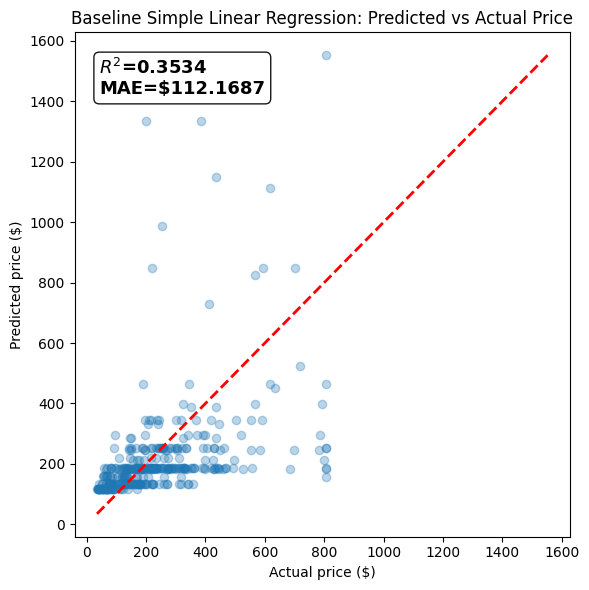

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Baseline Model
y_test_pred_log_lrb = lr_baseline.predict(X_test_scaled[base_features])

# Back-transform to dollars
y_test_actual = np.expm1(y_test)
y_test_pred_lrb = np.expm1(y_test_pred_log_lrb)

plt.figure(figsize=(6, 6))

plt.scatter(y_test_actual, y_test_pred_lrb, alpha=0.3)
min_val = min(y_test_actual.min(), y_test_pred_lrb.min())
max_val = max(y_test_actual.max(), y_test_pred_lrb.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

# Evaluation metrics text
textstr = f'$R^2$={base_r2_test:.4f}\nMAE=${base_mae_test_dollar:.4f}'
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes,
         fontsize=13, verticalalignment='top', fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

plt.xlabel('Actual price ($)')
plt.ylabel('Predicted price ($)')
plt.title('Baseline Simple Linear Regression: Predicted vs Actual Price')
plt.tight_layout()
plt.show()




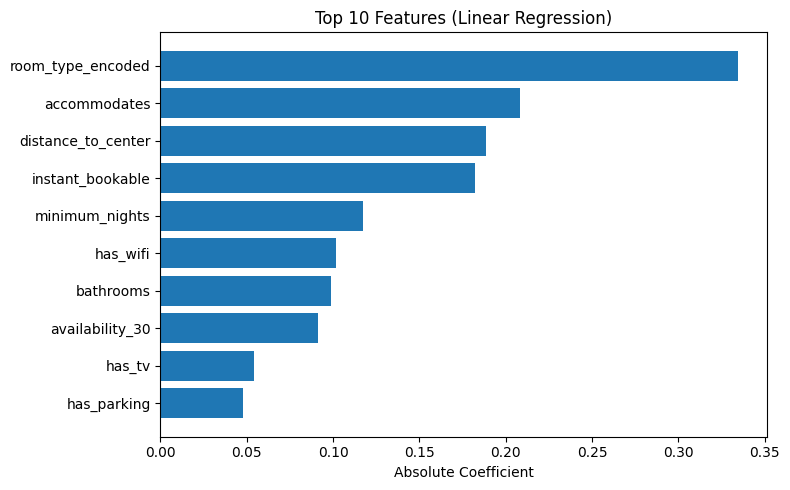

In [ ]:
# Manasa Praveen
# Bar Graph displaying the top 10 most important features analyzed by the Linear Regression Model
top_n = 10
top_features_lr = feature_importance_df_lr.head(top_n)

plt.figure(figsize=(8, 5))
plt.barh(top_features_lr['feature'], top_features_lr['abs_importance'])
plt.gca().invert_yaxis()
plt.xlabel('Absolute Coefficient')
plt.title(f'Top {top_n} Features (Linear Regression)')
plt.tight_layout()
plt.show()

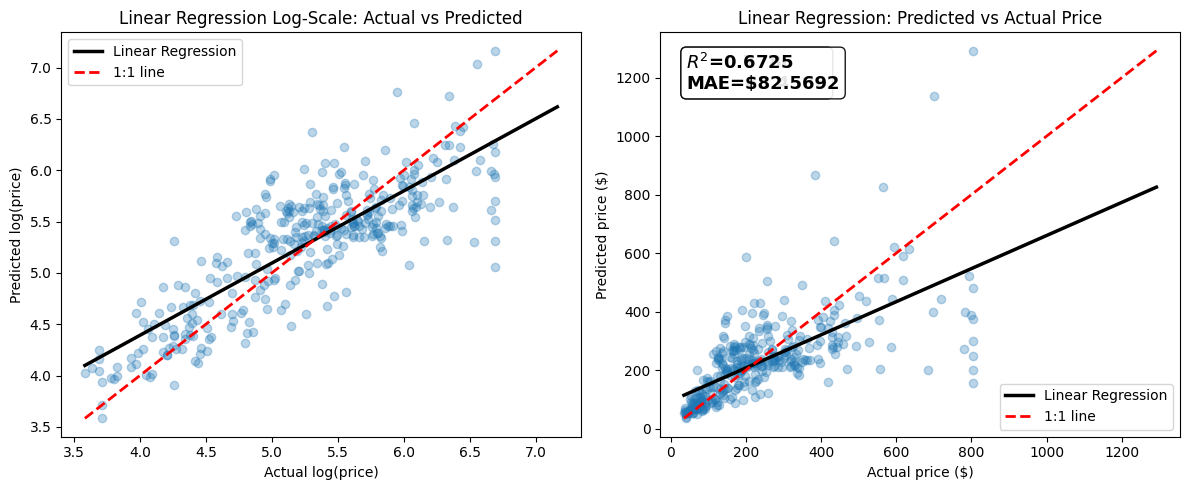

In [ ]:
# Manasa Praveen
# Comparison of actual vs. price predictions for Linear Regression
from scipy import stats
# Linear Regression predictions on test set
y_test_pred_log_lr = lr_model.predict(X_test_scaled)

# Back-transform to dollars
y_test_actual = np.expm1(y_test)
y_test_pred_lr = np.expm1(y_test_pred_log_lr)

# Create figure with 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Log(price) vs Log(predicted)
axes[0].scatter(y_test, y_test_pred_log_lr, alpha=0.3)
min_val = min(y_test.min(), y_test_pred_log_lr.min())
max_val = max(y_test.max(), y_test_pred_log_lr.max())

# linear regression
slope, intercept, _, _, _ = stats.linregress(y_test, y_test_pred_log_lr)
line_y = np.array([min_val, max_val])
axes[0].plot([min_val, max_val], slope * line_y + intercept, 'black', linewidth=2.5,
         label='Linear Regression')
# 1:1 line
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2,
         label = '1:1 line')
axes[0].legend()

axes[0].set_xlabel('Actual log(price)')
axes[0].set_ylabel('Predicted log(price)')
axes[0].set_title('Linear Regression Log-Scale: Actual vs Predicted')

textstr = f'$R^2$={r2_test_rf:.4f}\nMAE={mae_test_rf_dollar:.4f}'

# 2. Actual price vs Predicted price
axes[1].scatter(y_test_actual, y_test_pred_lr, alpha=0.3)
min_val = min(y_test_actual.min(), y_test_pred_lr.min())
max_val = max(y_test_actual.max(), y_test_pred_lr.max())
slope, intercept, _, _, _ = stats.linregress(y_test_actual, y_test_pred_lr)
line_y = np.array([min_val, max_val])
axes[1].plot([min_val, max_val], slope * line_y + intercept, 'black', linewidth=2.5,
         label='Linear Regression')
# 1:1 line
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2,
         label = '1:1 line')
axes[1].legend()
axes[1].text(0.05, 0.95, textstr, transform=plt.gca().transAxes,
         fontsize=13, verticalalignment='top', fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))


axes[1].set_xlabel('Actual price ($)')
axes[1].set_ylabel('Predicted price ($)')
axes[1].set_title('Actual Price: Actual vs Predicted')

# Evaluation metrics text
textstr = f'$R^2$={r2_test:.4f}\nMAE=${mae_test_dollar:.4f}'
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes,
         fontsize=13, verticalalignment='top', fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

plt.xlabel('Actual price ($)')
plt.ylabel('Predicted price ($)')
plt.title('Linear Regression: Predicted vs Actual Price')
plt.tight_layout()
plt.show()


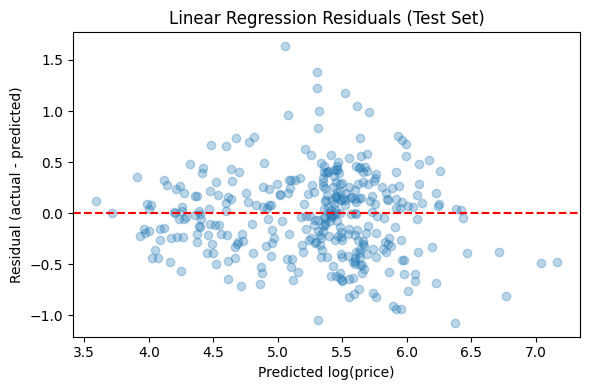

In [ ]:
# Manasa Praveen
# Linear Regression Residual
residuals_lr = y_test - y_test_pred_log_lr

plt.figure(figsize=(6, 4))
plt.scatter(y_test_pred_log_lr, residuals_lr, alpha=0.3)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('Predicted log(price)')
plt.ylabel('Residual (actual - predicted)')
plt.title('Linear Regression Residuals (Test Set)')
plt.tight_layout()
plt.show()


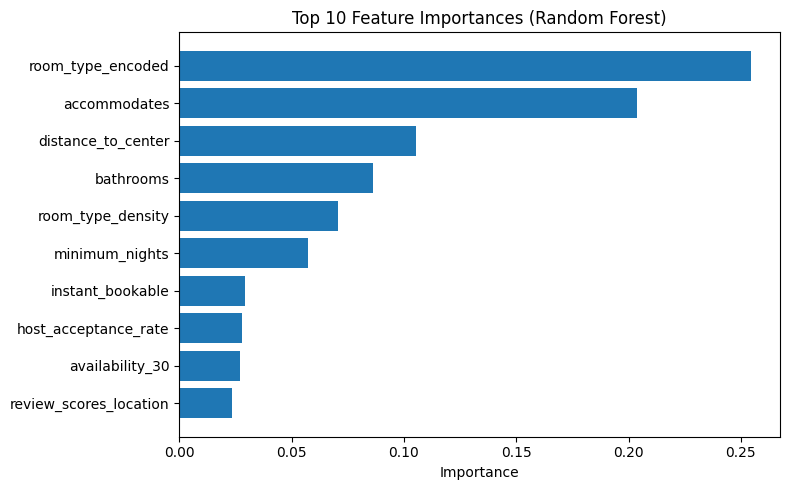

In [ ]:
# Manasa Praveen
# Bar Graph displaying the top 10 most important feature analyzed by the Random Forest Model
top_n = 10
top_features = feature_importance_df.head(top_n)

plt.figure(figsize=(8, 5))
plt.barh(top_features['feature'], top_features['importance'])
plt.gca().invert_yaxis()  # most important at top
plt.xlabel('Importance')
plt.title(f'Top {top_n} Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()

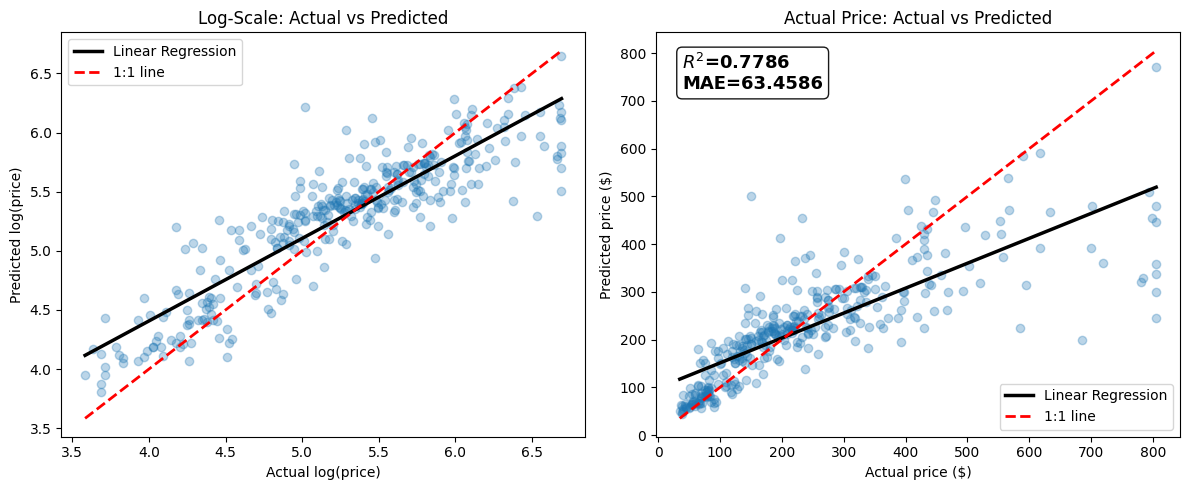

In [ ]:
# Manasa Praveen
# Comparison of log vs actual price predictions for Random Forest

# Random Forest predictions on test set (log scale)
y_test_pred_log = rf_model.predict(X_test_scaled)

# Back-transform to dollars
y_test_actual = np.expm1(y_test)
y_test_pred   = np.expm1(y_test_pred_log)

# Create figure with 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Log(price) vs Log(predicted)
axes[0].scatter(y_test, y_test_pred_log, alpha=0.3)
min_val = min(y_test.min(), y_test_pred_log.min())
max_val = max(y_test.max(), y_test_pred_log.max())

# linear regression
slope, intercept, _, _, _ = stats.linregress(y_test, y_test_pred_log)
line_y = np.array([min_val, max_val])
axes[0].plot([min_val, max_val], slope * line_y + intercept, 'black', linewidth=2.5,
         label='Linear Regression')
# 1:1 line
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2,
         label = '1:1 line')
axes[0].legend()

axes[0].set_xlabel('Actual log(price)')
axes[0].set_ylabel('Predicted log(price)')
axes[0].set_title('Log-Scale: Actual vs Predicted')

textstr = f'$R^2$={r2_test_rf:.4f}\nMAE={mae_test_rf_dollar:.4f}'

# 2. Actual price vs Predicted price
axes[1].scatter(y_test_actual, y_test_pred, alpha=0.3)
min_val = min(y_test_actual.min(), y_test_pred.min())
max_val = max(y_test_actual.max(), y_test_pred.max())
slope, intercept, _, _, _ = stats.linregress(y_test_actual, y_test_pred)
line_y = np.array([min_val, max_val])
axes[1].plot([min_val, max_val], slope * line_y + intercept, 'black', linewidth=2.5,
         label='Linear Regression')
# 1:1 line
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2,
         label = '1:1 line')
axes[1].legend()
axes[1].text(0.05, 0.95, textstr, transform=plt.gca().transAxes,
         fontsize=13, verticalalignment='top', fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))


axes[1].set_xlabel('Actual price ($)')
axes[1].set_ylabel('Predicted price ($)')
axes[1].set_title('Actual Price: Actual vs Predicted')

# Layout
plt.tight_layout()
plt.show()


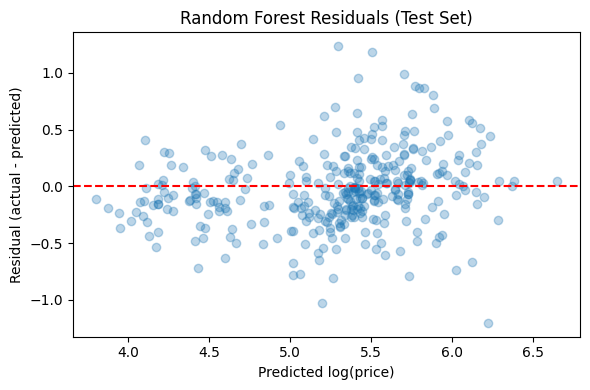

In [ ]:
# Manasa Praveen
# Random Forest Prediction Residual

residuals = y_test - y_test_pred_log

plt.figure(figsize=(6, 4))
plt.scatter(y_test_pred_log, residuals, alpha=0.3)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('Predicted log(price)')
plt.ylabel('Residual (actual - predicted)')
plt.title('Random Forest Residuals (Test Set)')
plt.tight_layout()
plt.show()

# **Error Analysis**


---- ANALYSIS 1: Error by Price Range ----

Error by Price Range:
             Mean_Error     MAE    MAPE  Count
price_range                                   
$0-100            20.75   28.58   24.28  36.45
$100-150          42.90   58.55   50.40  38.15
$150-200          34.87   44.80   43.09  24.31
$200-250          17.14   56.24   37.01  16.15
$250-300          -1.07   40.84   31.79  11.71
$300-400         -59.83   60.95   69.64  19.83
$400-500         -80.67   82.35   92.89  20.83
$500+           -264.97  163.39  264.97  37.62


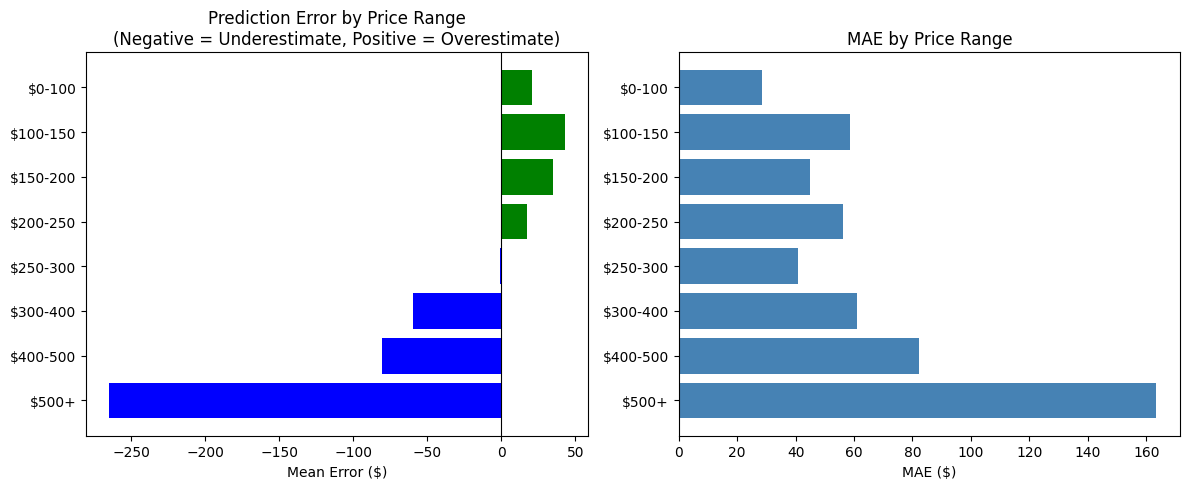


---- ANALYSIS 2: Error by Room Type ----

Error by Room Type:
                 Mean_Error     MAE    MAPE  Count  Avg_Price
room_type_name                                               
Entire home/apt      -18.99   73.20   26.93    251     283.47
Hotel room          -239.70  239.70   29.78      3     805.00
Private room          -4.70   32.29   26.25     96     116.77
Shared room           81.95   81.95  120.51      1      68.00


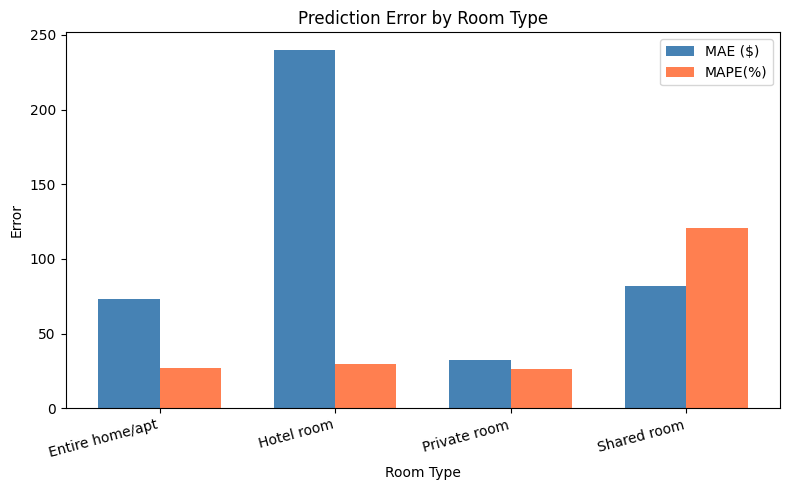


---- ANALYSIS 3: Error by Accommodate Size ----

Error by Accommodates:
           Mean_Error     MAE   MAPE  Count  Avg_Price
acc_range                                             
1               10.83   17.74  26.70     51      70.41
2               -9.96   48.55  24.80    134     213.50
3-4            -13.43   71.83  27.73     97     258.55
5-6            -52.31  112.06  30.07     40     366.25
7+             -57.80  117.71  31.40     29     445.31


In [ ]:
# Kexin Wang
# Base on the result of Random Forest
test_indices = X_test.index # get the indices from test set

error_df = pd.DataFrame({
    'actual_price_log' : y_test.values,
    'predicted_price_log': test_predictions_rf,
    'actual_price' : np.expm1(y_test.values),
    'predicted_price': np.expm1(test_predictions_rf),
}, index = test_indices)

# calculate errors
error_df['error'] = error_df['predicted_price'] - error_df['actual_price']
error_df['abs_error'] = np.abs(error_df['error'])
error_df['abs_pct_error'] = (error_df['abs_error'] / error_df['actual_price']) * 100


# add the features fot analysis
error_df['room_type'] = df.loc[test_indices, 'room_type_encoded']
error_df['accommodates'] = df.loc[test_indices, 'accommodates']

# error by price range
# base on the price distribution
print("\n---- ANALYSIS 1: Error by Price Range ----")
price_bins = [0, 100, 150, 200, 250, 300, 400, 500, np.inf]
price_labels = ['$0-100', '$100-150', '$150-200', '$200-250', '$250-300', '$300-400', '$400-500', '$500+']

error_df['price_range'] = pd.cut(error_df['actual_price'], bins=price_bins, labels=price_labels)

# 'error': ['mean', 'std']: show error bias direction
# positive: overestimate
# negative: underestimate
# 'abs_error': 'mean': MAE
# 'pct_error': 'mean': MAPE
price_analysis = error_df.groupby('price_range', observed=True).agg({
    'error': ['mean', 'std'],
    'abs_error': 'mean',
    'abs_pct_error': 'mean',
}).round(2)

price_analysis.columns = ['Mean_Error', 'MAE', 'MAPE', 'Count']
print("\nError by Price Range:")
print(price_analysis)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Mean Error by Price Range (shows bias)
colors = ['green' if x > 0 else 'blue' for x in price_analysis['Mean_Error']]
axes[0].barh(price_analysis.index.astype(str), price_analysis['Mean_Error'], color=colors)
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=0.8)
axes[0].set_xlabel('Mean Error ($)')
axes[0].set_title('Prediction Error by Price Range\n(Negative = Underestimate, Positive = Overestimate)')
axes[0].invert_yaxis()

# Plot 2: MAE by Price Range
axes[1].barh(price_analysis.index.astype(str), price_analysis['MAE'], color='steelblue')
axes[1].set_xlabel('MAE ($)')
axes[1].set_title('MAE by Price Range')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# error by room type
print("\n---- ANALYSIS 2: Error by Room Type ----")

room_type_map = {0: 'Entire home/apt', 1: 'Hotel room', 2: 'Private room', 3: 'Shared room'}
error_df['room_type_name'] = error_df['room_type'].map(room_type_map)

room_analysis = error_df.groupby('room_type_name', observed=True).agg({
    'error': 'mean',
    'abs_error': 'mean',
    'abs_pct_error': 'mean',
    'actual_price': ['count', 'mean']
}).round(2)

room_analysis.columns = ['Mean_Error', 'MAE', 'MAPE', 'Count', 'Avg_Price']
print("\nError by Room Type:")
print(room_analysis)

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(room_analysis))
width = 0.35

bars1 = ax.bar(x - width/2, room_analysis['MAE'], width, label='MAE ($)', color='steelblue')
bars2 = ax.bar(x + width/2, np.abs(room_analysis['MAPE']), width, label='MAPE(%)', color='coral')

ax.set_xlabel('Room Type')
ax.set_ylabel('Error')
ax.set_title('Prediction Error by Room Type')
ax.set_xticks(x)
ax.set_xticklabels(room_analysis.index, rotation=15, ha='right')
ax.legend()

plt.tight_layout()
plt.savefig('error_by_room_type.png', dpi=150, bbox_inches='tight')
plt.show()

# error by accomodates
print("\n---- ANALYSIS 3: Error by Accommodate Size ----")

acc_bins = [0, 1, 2, 4, 6, np.inf]
acc_labels = ['1', '2', '3-4', '5-6', '7+']
error_df['acc_range'] = pd.cut(error_df['accommodates'], bins=acc_bins, labels=acc_labels)

acc_analysis = error_df.groupby('acc_range', observed=True).agg({
    'error': 'mean',
    'abs_error': 'mean',
    'abs_pct_error': 'mean',
    'actual_price': ['count', 'mean']
}).round(2)

acc_analysis.columns = ['Mean_Error', 'MAE', 'MAPE', 'Count', 'Avg_Price']
print("\nError by Accommodates:")
print(acc_analysis)
